In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet

In [2]:
df = pd.read_csv("wiki_machine_learning.csv", sep=" ", engine="python")

# Keep only 2 columns We need
df_cleaned = df[["date", "count"]].copy()
df_cleaned["date"] = pd.to_datetime(df["date"])

df_cleaned = df_cleaned[df_cleaned["count"] != 0]

# reset indexes and sort by date
df_cleaned = df_cleaned.sort_values("date").reset_index(drop=True)

In [3]:
df_cleaned.head()

,date,count
0,2015-01-01,1414
1,2015-01-02,1920
2,2015-01-03,1338
3,2015-01-04,1404
4,2015-01-05,2264


## Prophet

In [4]:
df_prophet = df_cleaned.rename(columns={'date':'ds','count':'y'})

model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(df_prophet)

15:01:11 - cmdstanpy - INFO - Chain [1] start processing
15:01:11 - cmdstanpy - INFO - Chain [1] done processing


#### Future

In [5]:
future = model.make_future_dataframe(periods=30,freq='D')

# Forecast
forecast = model.predict(future)

# what we predicted for 30days
# forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(30)

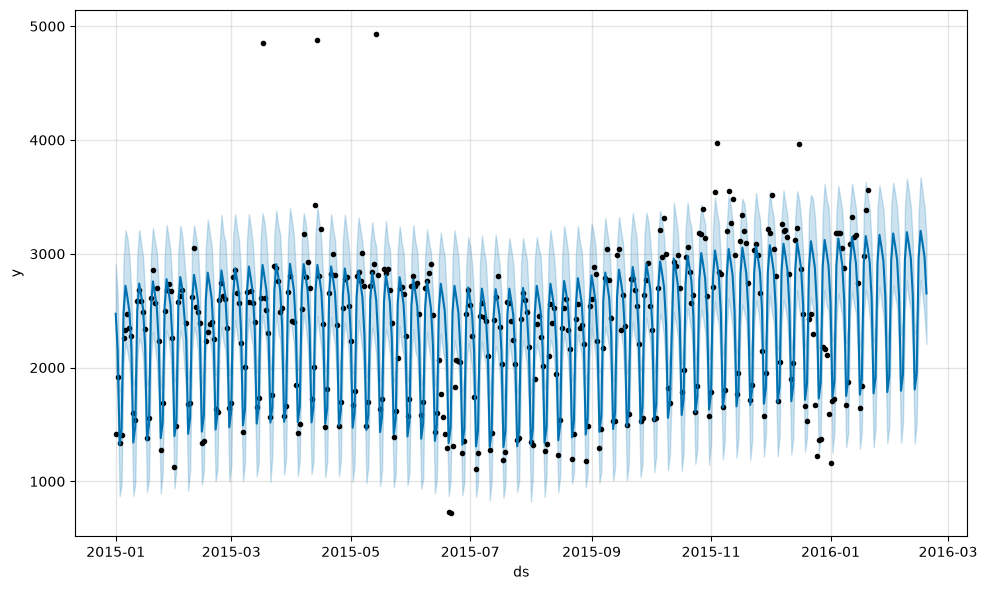

In [6]:
fig1 = model.plot(forecast)

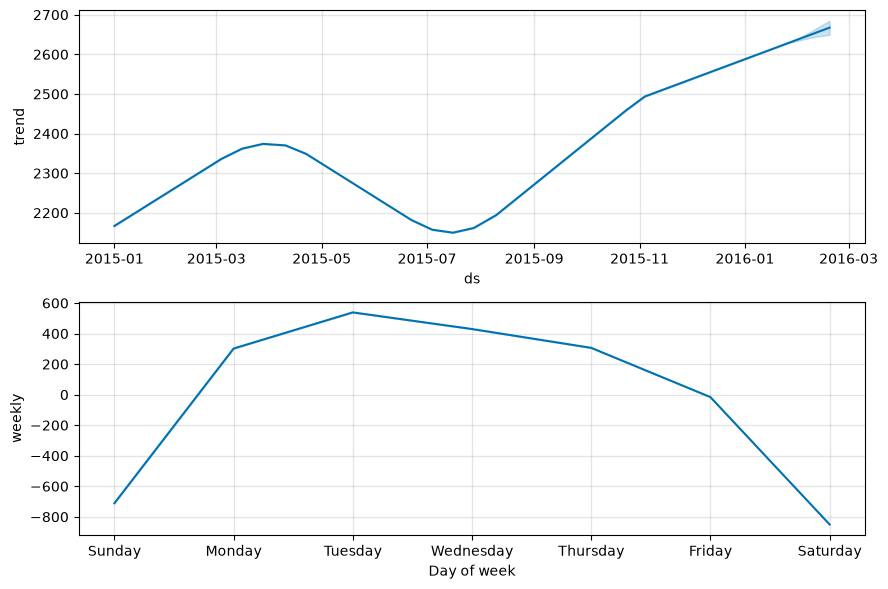

In [7]:
fig2 = model.plot_components(forecast)